In [1]:
!pip install imbalanced-ensemble


  DEPRECATION: Building 'liac-arff' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'liac-arff'. Discussion can be found at https://github.com/pypa/pip/issues/6334



  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/752.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/752.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/752.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/752.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/752.0 kB ? eta -:--:--
   ------------- -------------------------- 262.1/752.0 kB ? eta -:--:--
   ------------- -------------------------- 262.1/752.0 kB ? eta -:--:--
   ------------- -------------------------- 262.1/752.0 kB ? eta -:--:--
   ------------- -------------------------- 262.1/752.0 kB ? eta -:--:--
   -------------------------- ----------- 524.3/752.0 kB 308.3 kB/s eta 0:00:01
   -------------------------- ----------- 524.3/752.0 kB 308.3 kB/s eta 0:00:01
   -------------------------------------- 752.0/752.0 kB 338.6 kB/s eta 0:00:00
   -------

In [3]:
from imblearn.datasets import fetch_datasets


In [4]:
datasets = fetch_datasets()
data = datasets['mammography']

X = data.data
y = data.target

print(X.shape, y.shape)


(11183, 6) (11183,)


In [6]:
import pandas as pd

# Column names
columns = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness"
]

# Create DataFrame
df = pd.DataFrame(X, columns=columns)

# Add target column
df["target"] = y

# Convert target from -1/+1 to 0/1
# -1 -> 0 (Benign)
#  1 -> 1 (Malignant)
df["target"] = df["target"].map({-1: 0, 1: 1})

# Verify conversion
print(df["target"].value_counts())

# Update X and y
X = df.drop("target", axis=1).values
y = df["target"].values

# Display first 5 rows
df.head()



target
0    10923
1      260
Name: count, dtype: int64


,radius,texture,perimeter,area,smoothness,compactness,target
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,0
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,0
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,0
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,0
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11183 entries, 0 to 11182
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   radius       11183 non-null  float64
 1   texture      11183 non-null  float64
 2   perimeter    11183 non-null  float64
 3   area         11183 non-null  float64
 4   smoothness   11183 non-null  float64
 5   compactness  11183 non-null  float64
 6   target       11183 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 611.7 KB


In [7]:
df.shape


(11183, 7)

In [8]:
df["target"].value_counts()

target
0    10923
1      260
Name: count, dtype: int64

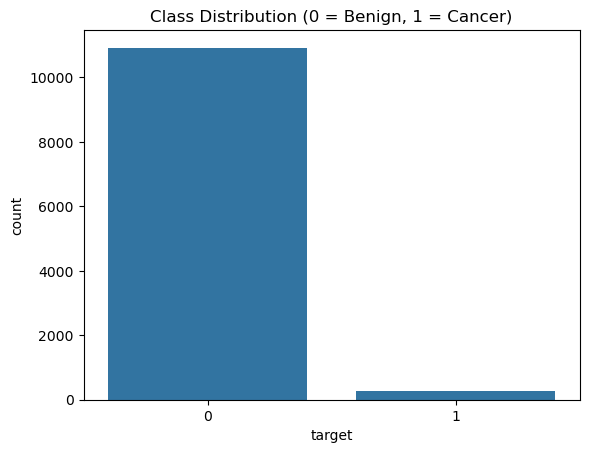

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Class Distribution (0 = Benign, 1 = Cancer)")
plt.show()


In [12]:
df.describe()


,radius,texture,perimeter,area,smoothness,compactness,target
count,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04,11183.000000
mean,1.096536e-10,1.297595e-09,5.698113e-10,-2.435706e-09,-1.120680e-09,1.459483e-09,0.023250
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.150702
min,-7.844148e-01,-4.701953e-01,-5.916315e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01,0.000000
25%,-7.844148e-01,-4.701953e-01,-5.916315e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01,0.000000
50%,-1.085769e-01,-3.949941e-01,-2.309790e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01,0.000000
75%,3.139489e-01,-7.649473e-02,2.198366e-01,8.202077e-01,-3.778657e-01,1.016613e+00,0.000000
max,3.150844e+01,5.085849e+00,2.947777e+01,9.591164e+00,2.361712e+01,1.949027e+00,1.000000


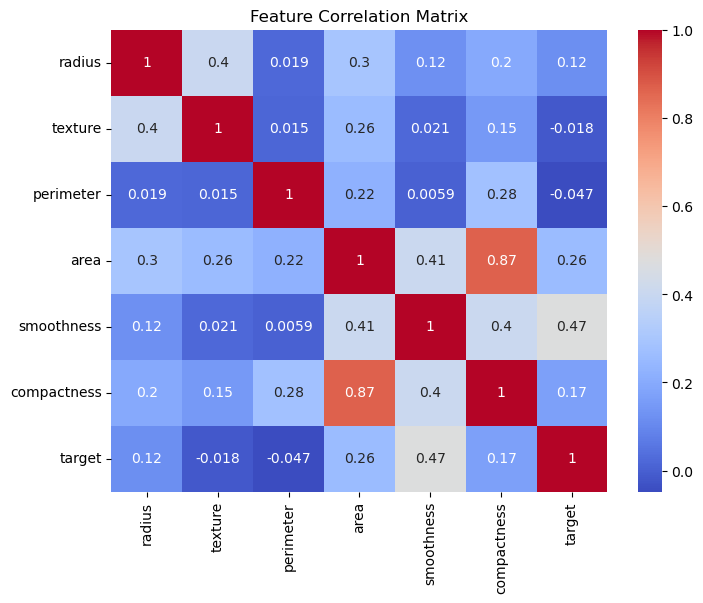

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [14]:
X = df.drop("target", axis=1)
y = df["target"]


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline


In [17]:
preprocess_pipeline = Pipeline([
    ("scaler", StandardScaler())
])


In [18]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [19]:
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),        # scale features
    ("smote", SMOTE(random_state=42)),   # handle imbalance
    ("model", LogisticRegression(class_weight="balanced"))
])


In [20]:
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(class_weight='balanced'))])

In [21]:
y_pred = model_pipeline.predict(X_test)


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.91      0.95      2185
           1       0.20      0.96      0.33        52

    accuracy                           0.91      2237
   macro avg       0.60      0.93      0.64      2237
weighted avg       0.98      0.91      0.94      2237



In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    scoring="f1",
    cv=cv
)

print("F1 scores for each fold:", f1_scores)
print("Average F1 score:", f1_scores.mean())


F1 scores for each fold: [0.26022305 0.296      0.25899281 0.27091633 0.26778243]
Average F1 score: 0.2707829231044261


In [24]:
from sklearn.metrics import roc_auc_score

y_prob = model_pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC score:", roc_auc)


ROC-AUC score: 0.9700492870973421


In [25]:
import joblib

joblib.dump(model_pipeline, "breast_cancer_model.pkl")


['breast_cancer_model.pkl']

In [26]:
loaded_model = joblib.load("breast_cancer_model.pkl")


In [27]:
loaded_model.predict(X_test)


array([0, 0, 0, ..., 0, 0, 0])

In [28]:
type(loaded_model)


imblearn.pipeline.Pipeline

In [29]:
import numpy as np
np.unique(loaded_model.predict(X_test), return_counts=True)


(array([0, 1]), array([1982,  255]))